## Импорты и функции

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller
import statsmodels.tsa.api as smt
from scipy.stats import boxcox

%matplotlib inline

## Функции анализа временного ряда

In [8]:
def test_stationarity(series):
    result = adfuller(series)
    return {
        'adf_stat': result[0],
        'p_value': result[1],
        'lags': result[2],
        'n_obs': result[3]
    }

def tsplot(series, lags=30):
    fig, axes = plt.subplots(3, 1, figsize=(12, 8))
    series.plot(ax=axes[0], title='Time series')
    smt.graphics.plot_acf(series, lags=lags, ax=axes[1])
    smt.graphics.plot_pacf(series, lags=lags, ax=axes[2])
    plt.tight_layout()
    plt.show()

    print(test_stationarity(series))

## Загрузка рядов

In [9]:
files = {
    'sales': 'monthly-sales-of-company-x-jan-6.csv',
    'robberies': 'monthly-boston-armed-robberies-j.csv',
    'airline': 'international-airline-passengers.csv',
    'temperature': 'mean-monthly-air-temperature-deg.csv',
    'dowjones': 'weekly-closings-of-the-dowjones-.csv',
    'births': 'daily-total-female-births-in-cal.csv'
}

series = {}

for name, path in files.items():
    df = pd.read_csv(path)
    series[name] = df.iloc[:, -1]

## Первичный анализ (нестационарность)

sales


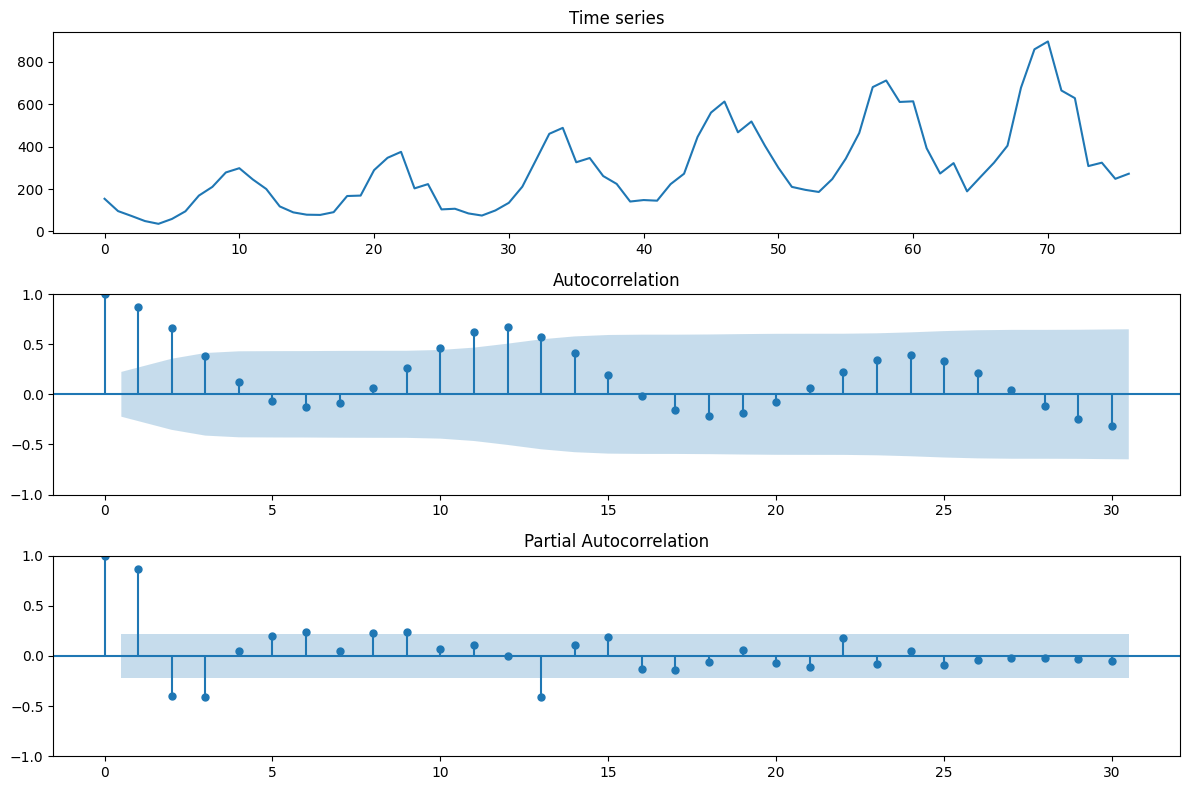

{'adf_stat': np.float64(0.6547150829524443), 'p_value': np.float64(0.9888894205170052), 'lags': 12, 'n_obs': 64}
robberies


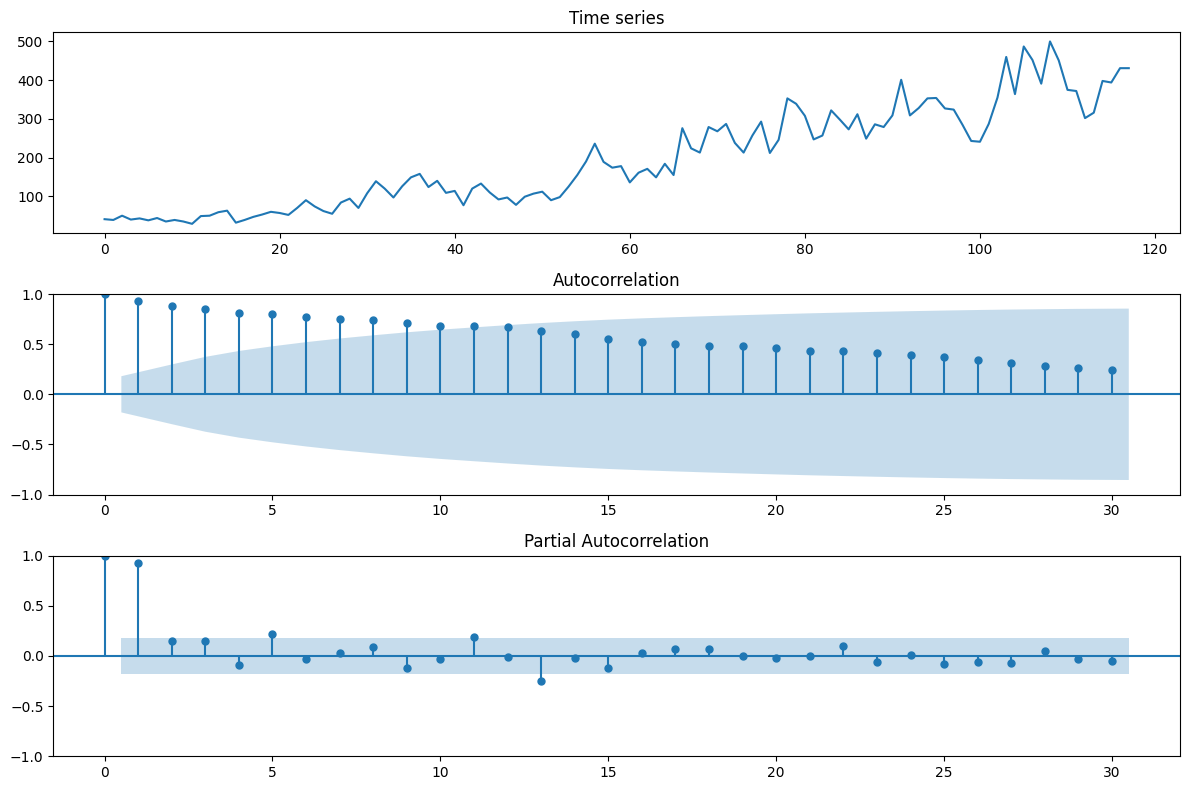

{'adf_stat': np.float64(1.0011021402457787), 'p_value': np.float64(0.994277563805723), 'lags': 11, 'n_obs': 106}
airline


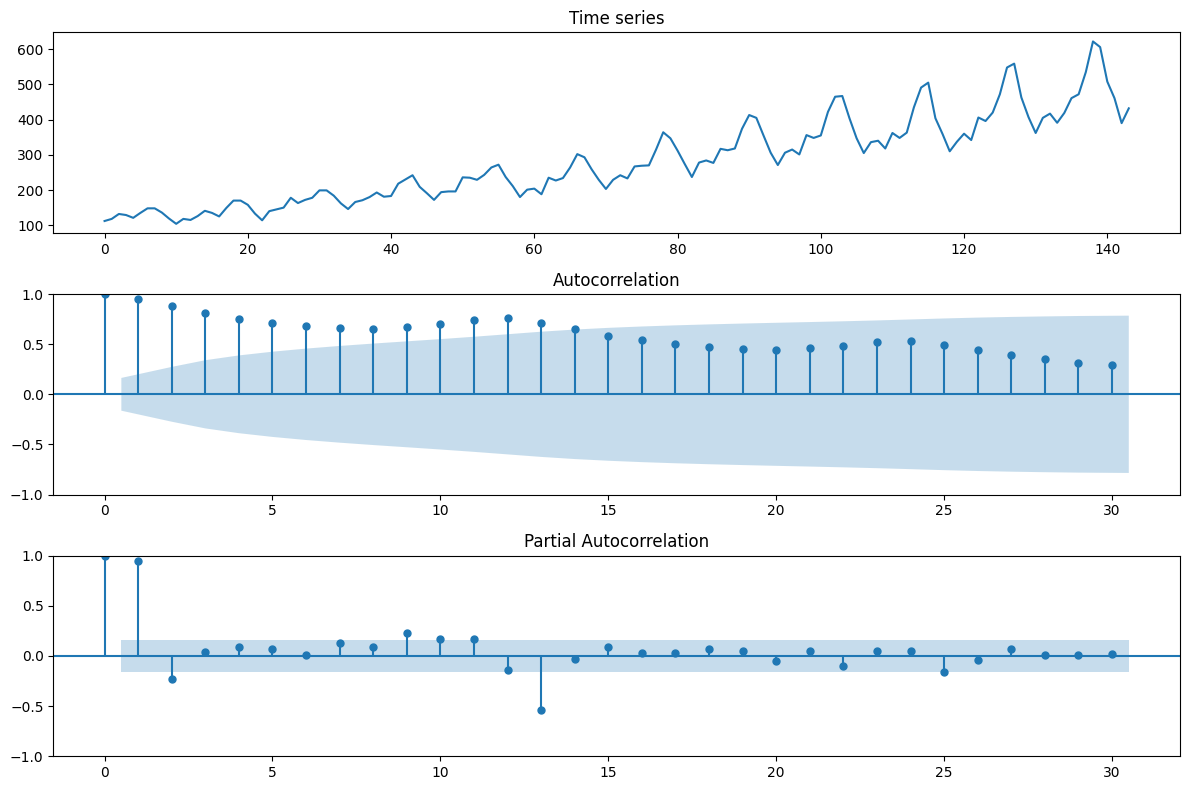

{'adf_stat': np.float64(0.8153688792060482), 'p_value': np.float64(0.991880243437641), 'lags': 13, 'n_obs': 130}
temperature


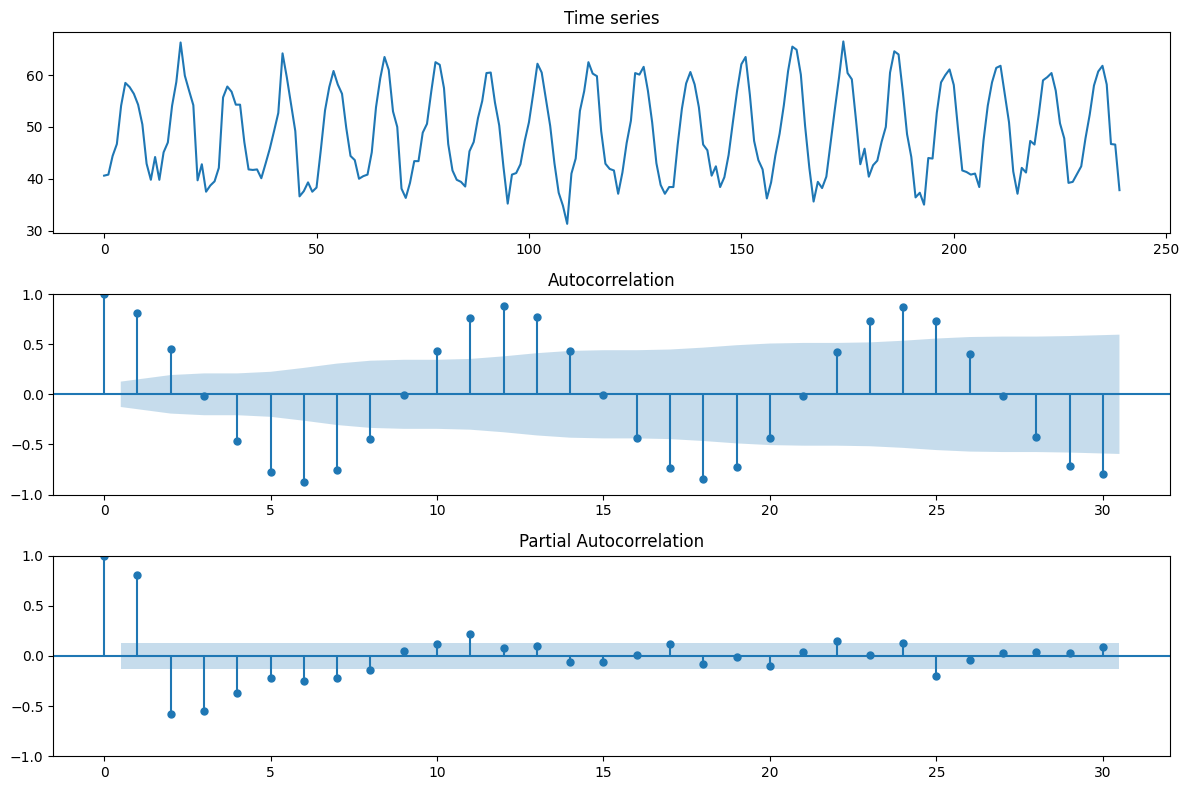

{'adf_stat': np.float64(-3.2554924030863353), 'p_value': np.float64(0.016989030222608687), 'lags': 14, 'n_obs': 225}
dowjones


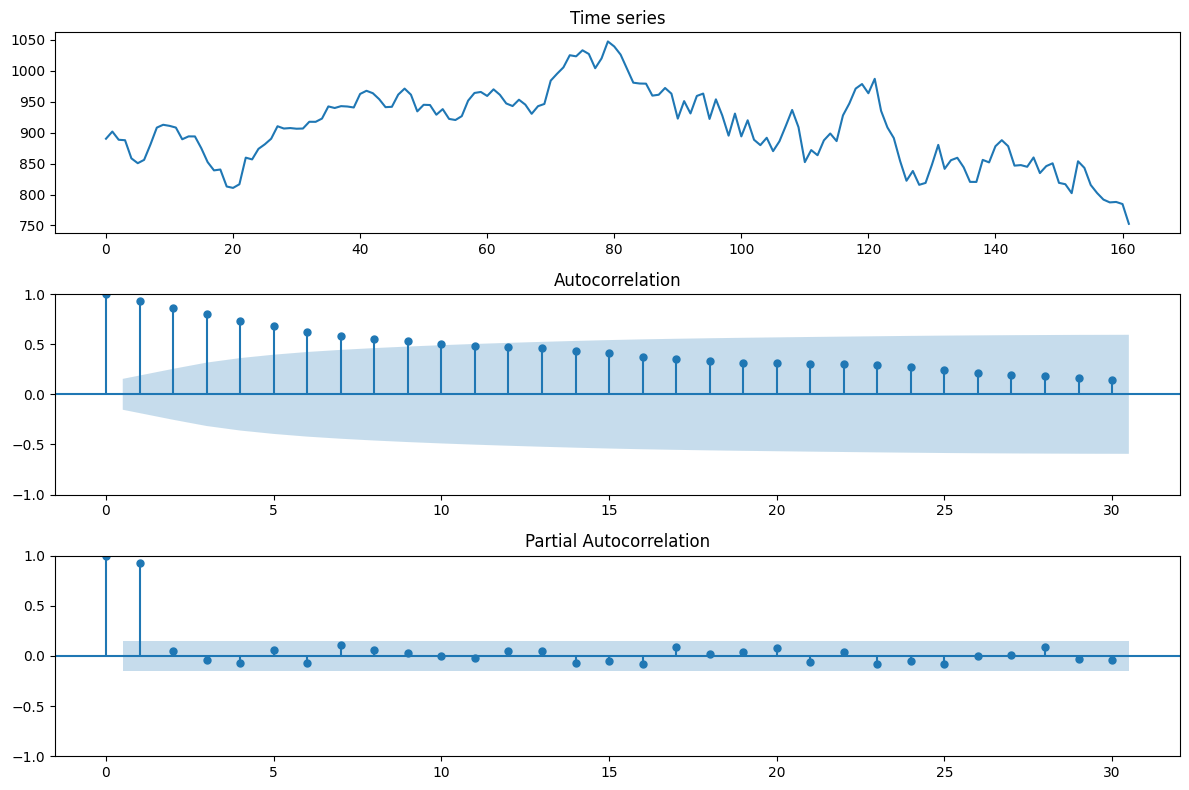

{'adf_stat': np.float64(-1.3146254984911718), 'p_value': np.float64(0.6224548515589717), 'lags': 0, 'n_obs': 161}
births


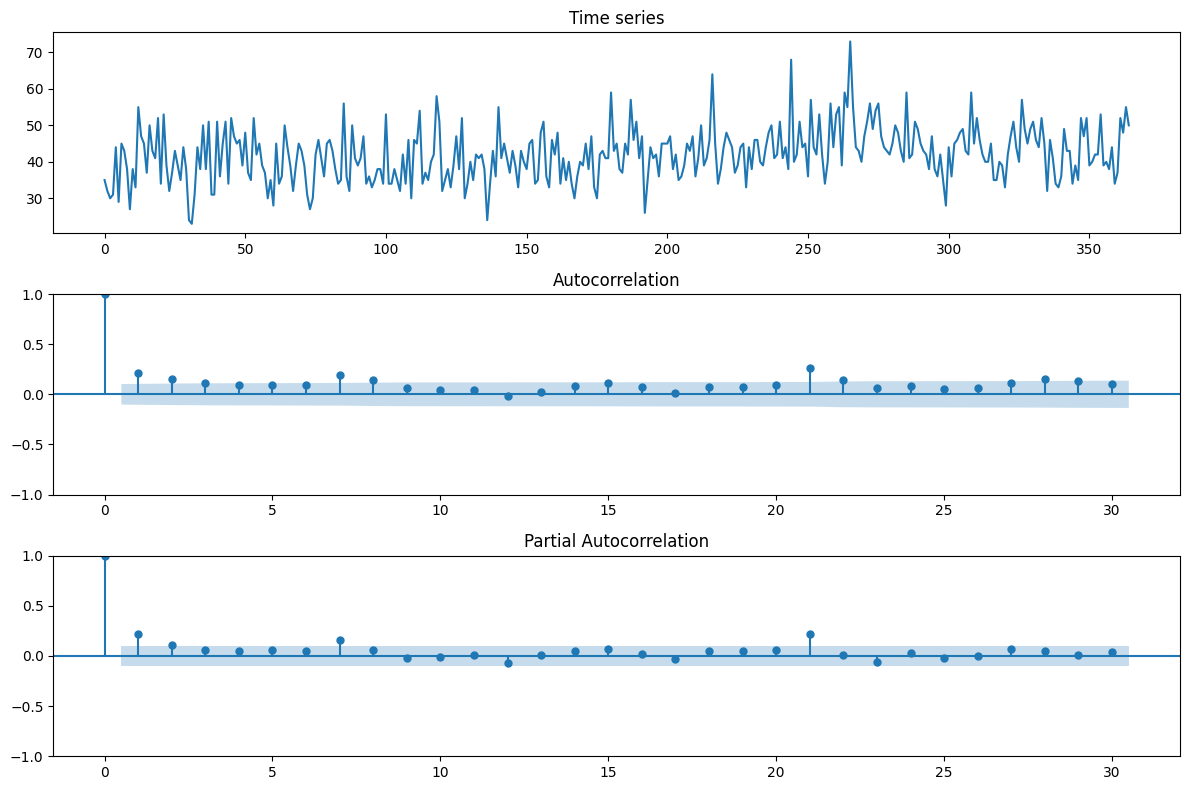

{'adf_stat': np.float64(-4.808291253559763), 'p_value': np.float64(5.243412990149865e-05), 'lags': 6, 'n_obs': 358}


In [10]:
for name, s in series.items():
    print(name)
    tsplot(s)

## Приведение к стационарности

Общая стратегия:

* Box-Cox - если меняется дисперсия
* Дифференцирование - если есть тренд
* Сезонное дифференцирование - при сезонности

In [11]:
stationary_series = {}

for name, s in series.items():
    s = s.dropna()

    if name == 'airline':
        s = boxcox(s, 0)
        s = np.diff(s, 12)
    elif name in ['sales', 'robberies', 'dowjones']:
        s = np.diff(s)
    elif name == 'temperature':
        s = np.diff(s, 12)

    stationary_series[name] = s

## Проверка стационарности

sales


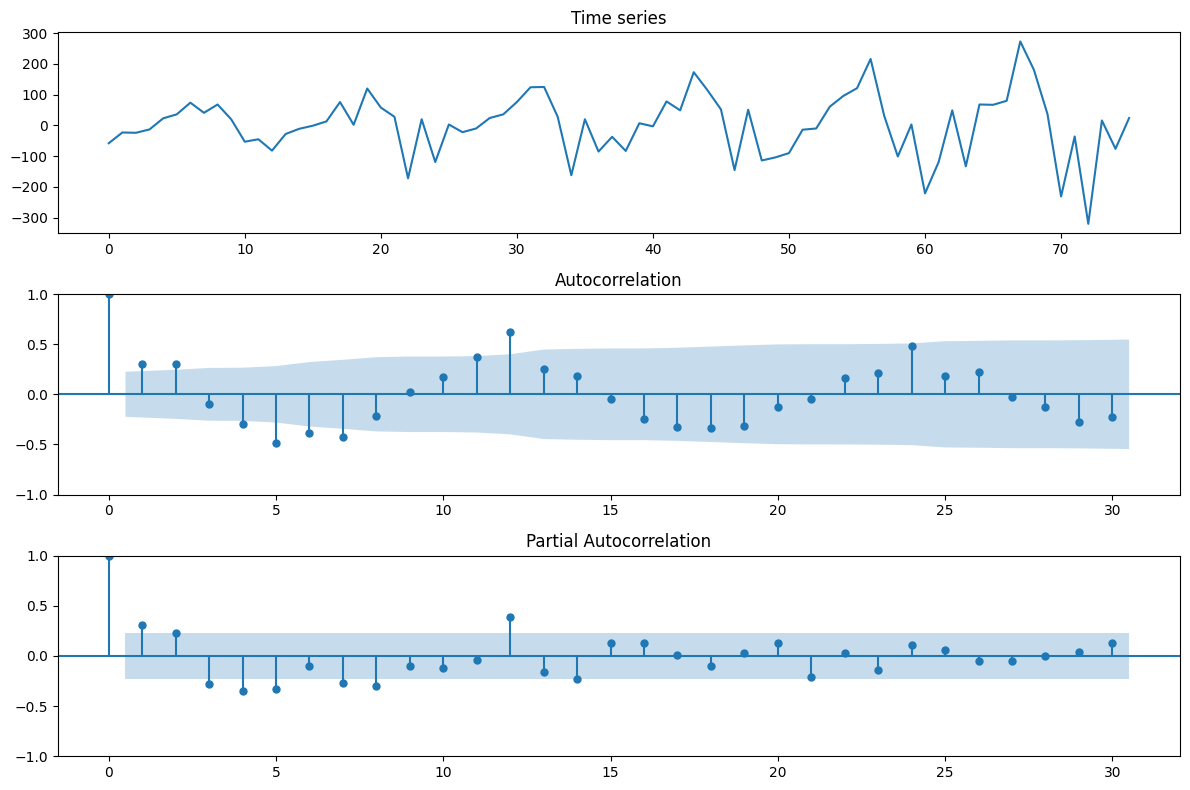

{'adf_stat': np.float64(-2.58796976706295), 'p_value': np.float64(0.09550925078558842), 'lags': 12, 'n_obs': 63}
robberies


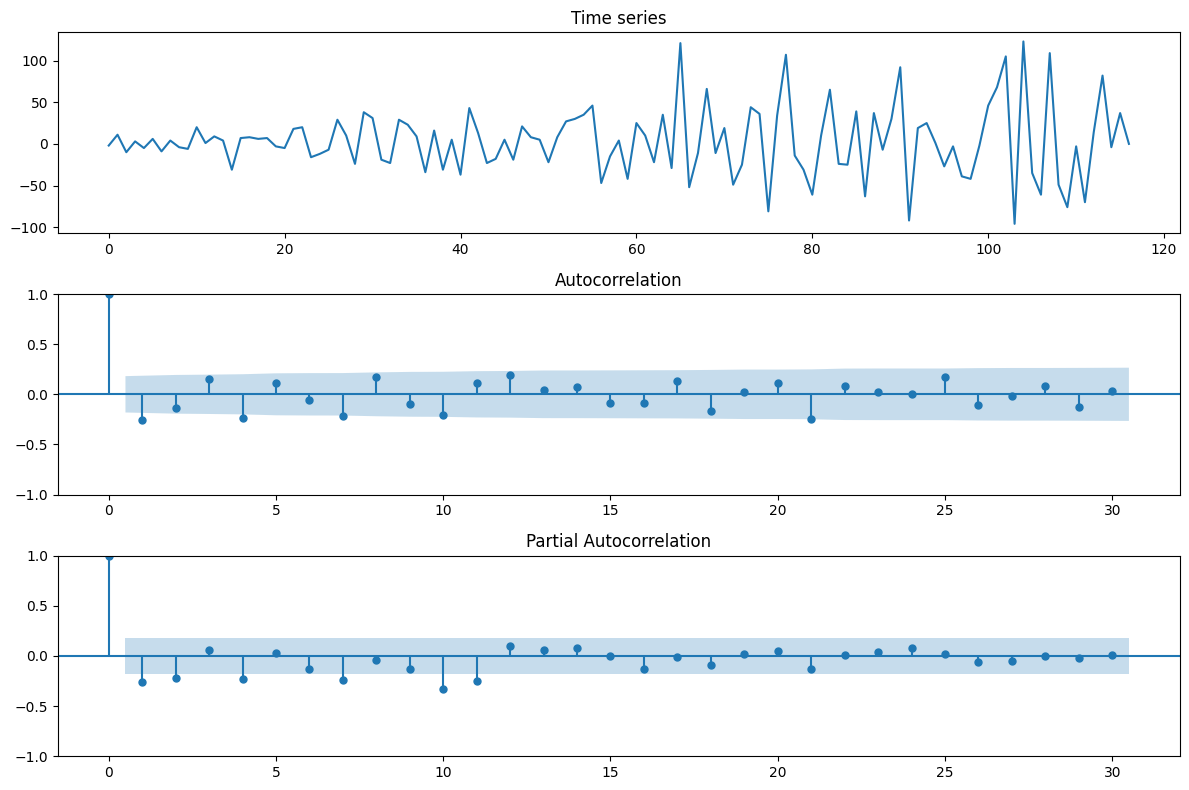

{'adf_stat': np.float64(-7.428564475067206), 'p_value': np.float64(6.450795412686752e-11), 'lags': 10, 'n_obs': 106}
airline


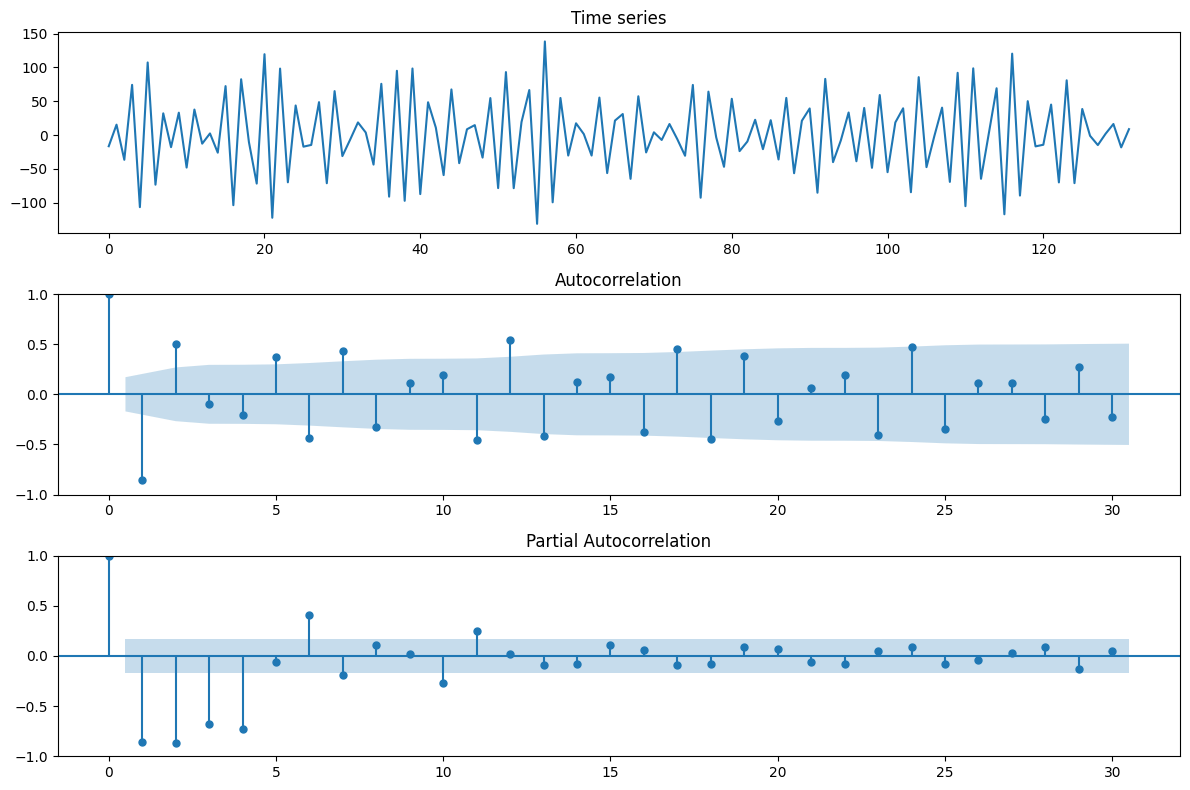

{'adf_stat': np.float64(-16.0605998605581), 'p_value': np.float64(5.644460839559857e-29), 'lags': 13, 'n_obs': 118}
temperature


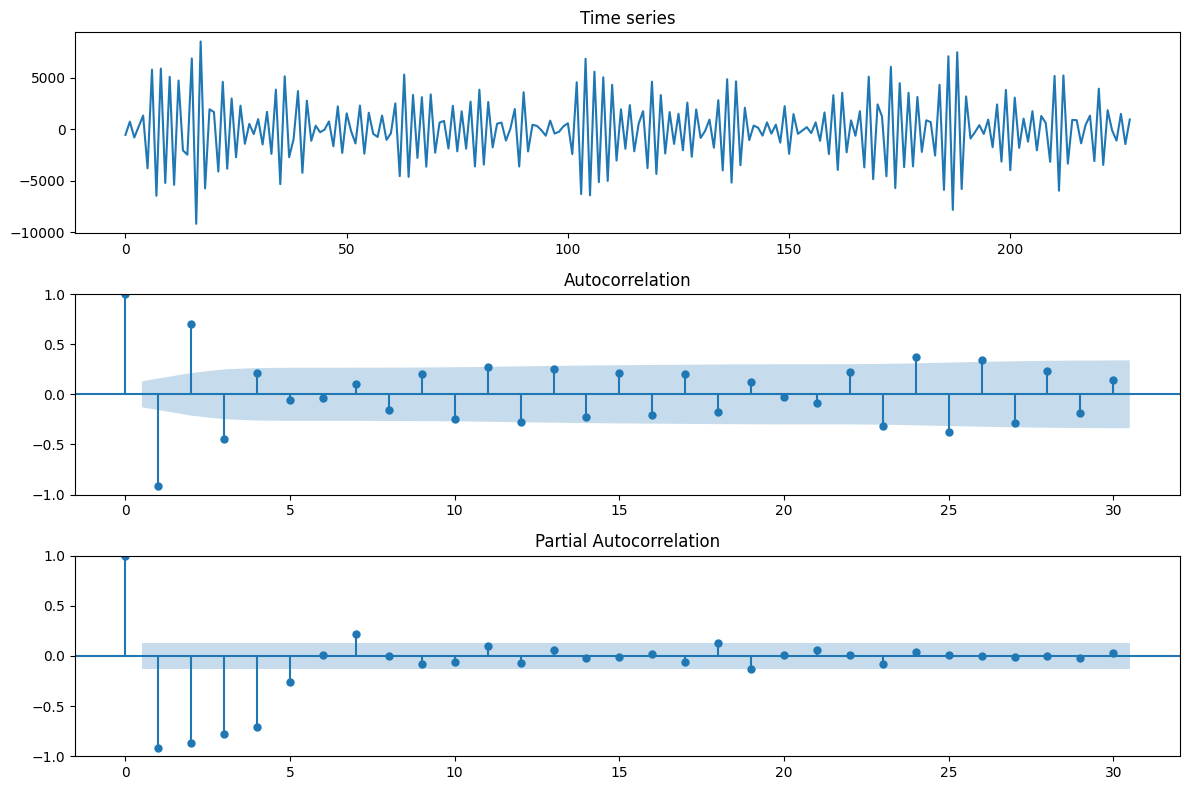

{'adf_stat': np.float64(-16.728941075458167), 'p_value': np.float64(1.3883424299470376e-29), 'lags': 15, 'n_obs': 212}
dowjones


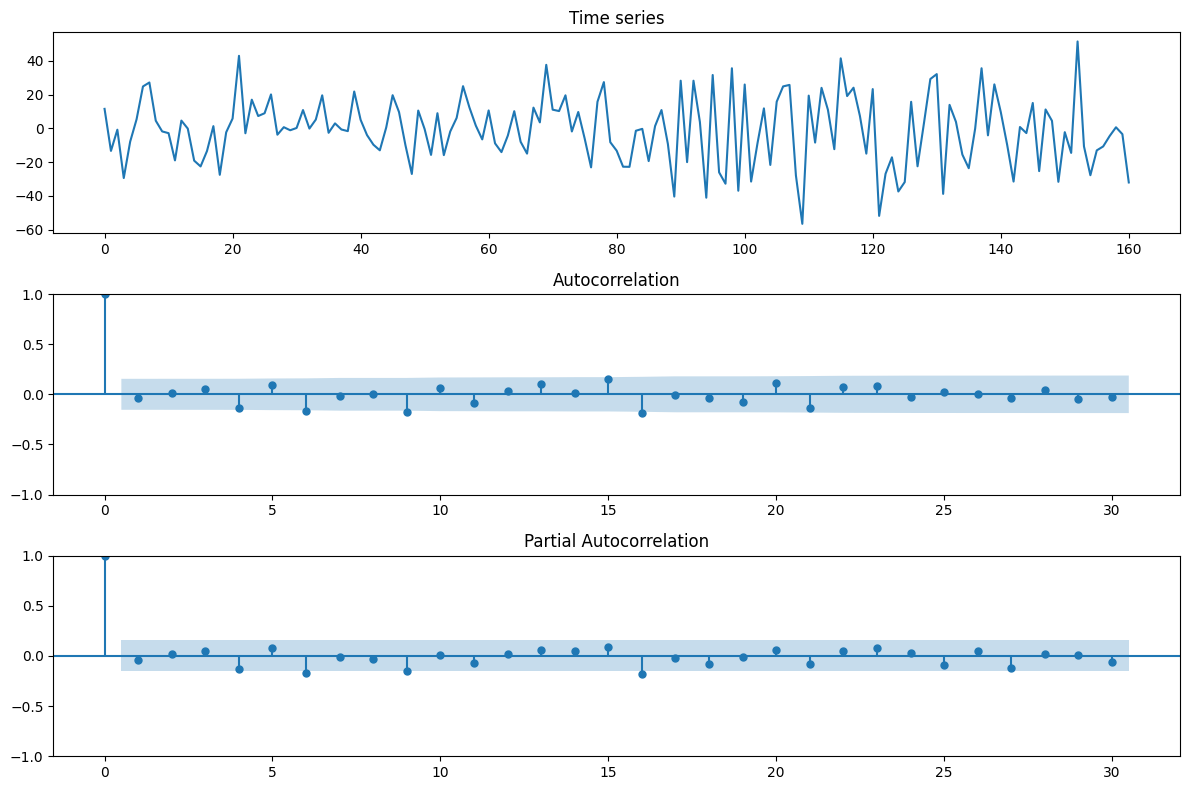

{'adf_stat': np.float64(-13.025207881234948), 'p_value': np.float64(2.4075864037417794e-24), 'lags': 0, 'n_obs': 160}
births


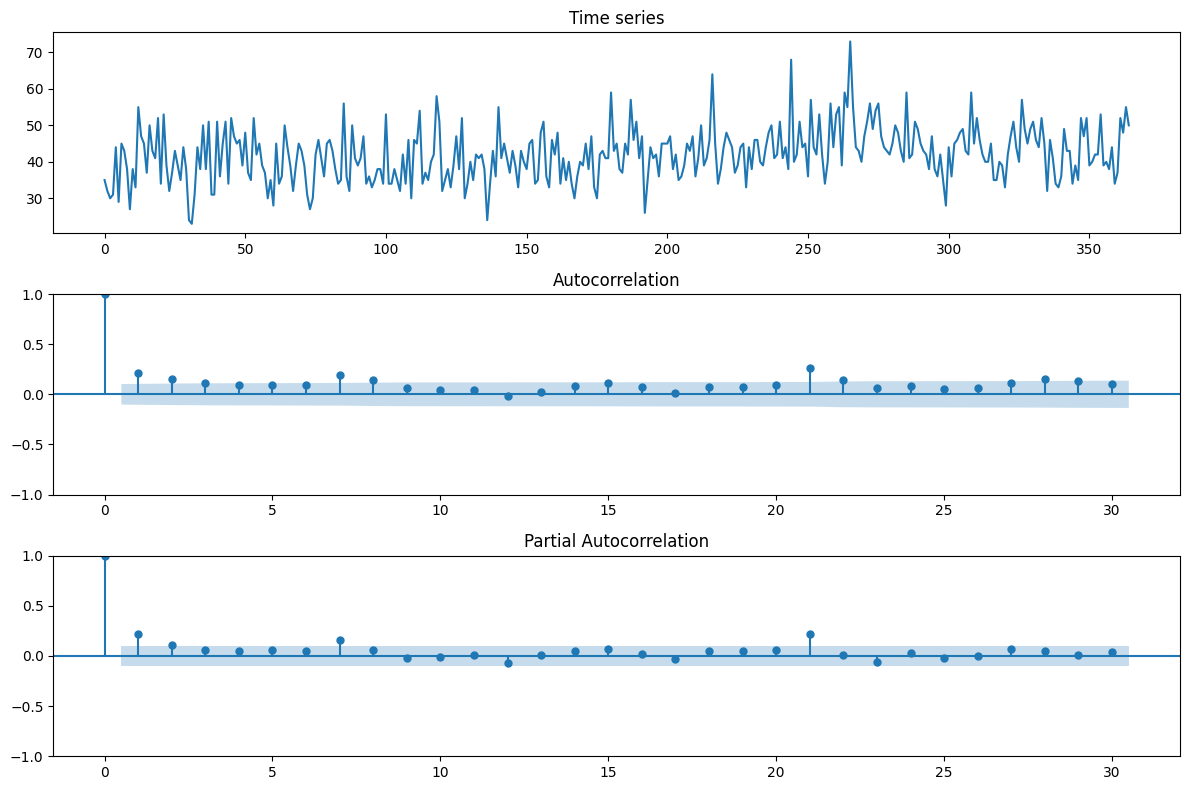

{'adf_stat': np.float64(-4.808291253559763), 'p_value': np.float64(5.243412990149865e-05), 'lags': 6, 'n_obs': 358}


In [12]:
for name, s in stationary_series.items():
    print(name)
    tsplot(pd.Series(s))

В ходе лабораторной работы были проанализированы шесть временных рядов различной природы.
Для каждого ряда проведён визуальный анализ, исследованы автокорреляционная и частичная автокорреляционная функции, а также выполнен тест Дики–Фуллера.

Было показано, что исходные ряды в общем случае являются нестационарными вследствие наличия тренда, сезонности или изменяющейся дисперсии.
В зависимости от выявленного источника нестационарности применялись различные преобразования: обычное и сезонное дифференцирование, а также преобразование Бокса–Кокса.

После преобразований все ряды стали стационарными, что подтверждается значениями p-value теста Дики–Фуллера и поведением коррелограмм.
Использование индивидуального подхода к каждому временному ряду позволило корректно устранить нестационарность без избыточных преобразований.